In [ ]:
from google.colab import files
uploaded = files.upload()   # <-- click button, upload pearl_dataset.csv

import pandas as pd
import numpy as np

df = pd.read_csv('pearl_dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Saving pearl_dataset.csv to pearl_dataset (2).csv
Shape: (1600, 13)

First 5 rows:


,level_number,session_number,sessions_on_current_level,session_accuracy,correct_placements,wrong_placements,rounds_completed,session_duration_sec,avg_reaction_time_ms,accuracy_last_3_sessions,accuracy_trend,time_trend,recommended_level
0,2,7,6,91.83,13,3,14,220.5,2171.0,48.74,10.212,13.249,stay
1,4,5,4,55.73,7,3,8,205.2,1890.8,64.52,-5.777,-3.738,stay
2,5,9,8,90.06,8,2,5,172.6,1738.8,83.07,1.220,1.489,stay
3,3,6,5,70.70,6,2,4,261.2,2418.8,57.18,-1.560,21.115,stay
4,3,8,7,100.00,3,5,9,238.1,2544.2,85.37,2.148,10.581,promote


In [ ]:
print("=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== LABEL COUNTS (what we are predicting) ===")
print(df['recommended_level'].value_counts())

print("\n=== LEVEL DISTRIBUTION ===")
print(df['level_number'].value_counts().sort_index())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
df.describe().round(2)

=== COLUMN NAMES ===
['level_number', 'session_number', 'sessions_on_current_level', 'session_accuracy', 'correct_placements', 'wrong_placements', 'rounds_completed', 'session_duration_sec', 'avg_reaction_time_ms', 'accuracy_last_3_sessions', 'accuracy_trend', 'time_trend', 'recommended_level']

=== LABEL COUNTS (what we are predicting) ===
recommended_level
stay       950
demote     350
promote    300
Name: count, dtype: int64

=== LEVEL DISTRIBUTION ===
level_number
1    280
2    410
3    320
4    370
5    220
Name: count, dtype: int64

=== MISSING VALUES ===
level_number                 0
session_number               0
sessions_on_current_level    0
session_accuracy             0
correct_placements           0
wrong_placements             0
rounds_completed             0
session_duration_sec         0
avg_reaction_time_ms         0
accuracy_last_3_sessions     0
accuracy_trend               0
time_trend                   0
recommended_level            0
dtype: int64

=== BASIC STATS

,level_number,session_number,sessions_on_current_level,session_accuracy,correct_placements,wrong_placements,rounds_completed,session_duration_sec,avg_reaction_time_ms,accuracy_last_3_sessions,accuracy_trend,time_trend
count,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00
mean,2.90,5.50,4.50,60.19,7.55,3.13,7.14,207.18,2412.75,60.70,-0.23,0.16
std,1.31,2.87,2.87,18.95,2.52,1.92,3.17,54.69,594.22,13.91,6.15,19.56
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,60.00,843.70,17.45,-32.67,-90.33
25%,2.00,3.00,2.00,47.33,6.00,2.00,5.00,170.20,1990.78,51.54,-3.78,-10.84
50%,3.00,5.50,4.50,60.86,8.00,3.00,7.00,204.65,2395.45,60.96,0.00,0.00
75%,4.00,8.00,7.00,73.56,9.00,4.00,9.00,242.62,2847.90,70.59,3.33,11.04
max,5.00,10.00,9.00,100.00,15.00,11.00,16.00,416.90,4293.60,100.00,25.22,101.73


In [ ]:
# EXPLANATION:
# X = the 12 input features the model learns from
# y = the label the model tries to predict (promote / stay / demote)
# We convert text labels into numbers because ML models work with numbers only.
# promote = 2, stay = 1, demote = 0

from sklearn.preprocessing import LabelEncoder

FEATURES = [
    'level_number',
    'session_number',
    'sessions_on_current_level',
    'session_accuracy',
    'correct_placements',
    'wrong_placements',
    'rounds_completed',
    'session_duration_sec',
    'avg_reaction_time_ms',
    'accuracy_last_3_sessions',
    'accuracy_trend',
    'time_trend',
]

X = df[FEATURES]
y = df['recommended_level']

# Encode labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

print("\nX shape:", X.shape)
print("y shape:", y_encoded.shape)
print("\nNo missing values?", X.isnull().sum().sum() == 0)

Label mapping:
  0 = demote
  1 = promote
  2 = stay

X shape: (1600, 12)
y shape: (1600,)

No missing values? True


In [ ]:
# EXPLANATION:
# We split data 80% for training, 20% for testing.
# The model never sees the test data during training.
# This lets us measure how well it works on new, unseen data.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded     # ensures all 3 labels appear in both splits
)

# Scale features — brings all numbers to same range
# Required for KNN and SVM, harmless for others
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

print("\nLabel split in training:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {(y_train == i).sum()}")

Training rows: 1280
Testing rows:  320

Label split in training:
  demote: 280
  promote: 240
  stay: 760


In [ ]:
from sklearn.naive_bayes    import GaussianNB
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.svm            import SVC

models = {
    'Naive Bayes':      GaussianNB(),
    'Decision Tree':    DecisionTreeClassifier(random_state=42),
    'Random Forest':    RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN':              KNeighborsClassifier(n_neighbors=5),
    'SVM':              SVC(kernel='rbf', probability=True, random_state=42),
}

trained = {}

for name, model in models.items():
    # SVM and KNN need scaled data, others work with raw
    if name in ['KNN', 'SVM']:
        model.fit(X_train_sc, y_train)
    else:
        model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")

print("\nAll 5 models trained successfully.")

Trained: Naive Bayes
Trained: Decision Tree
Trained: Random Forest
Trained: KNN
Trained: SVM

All 5 models trained successfully.


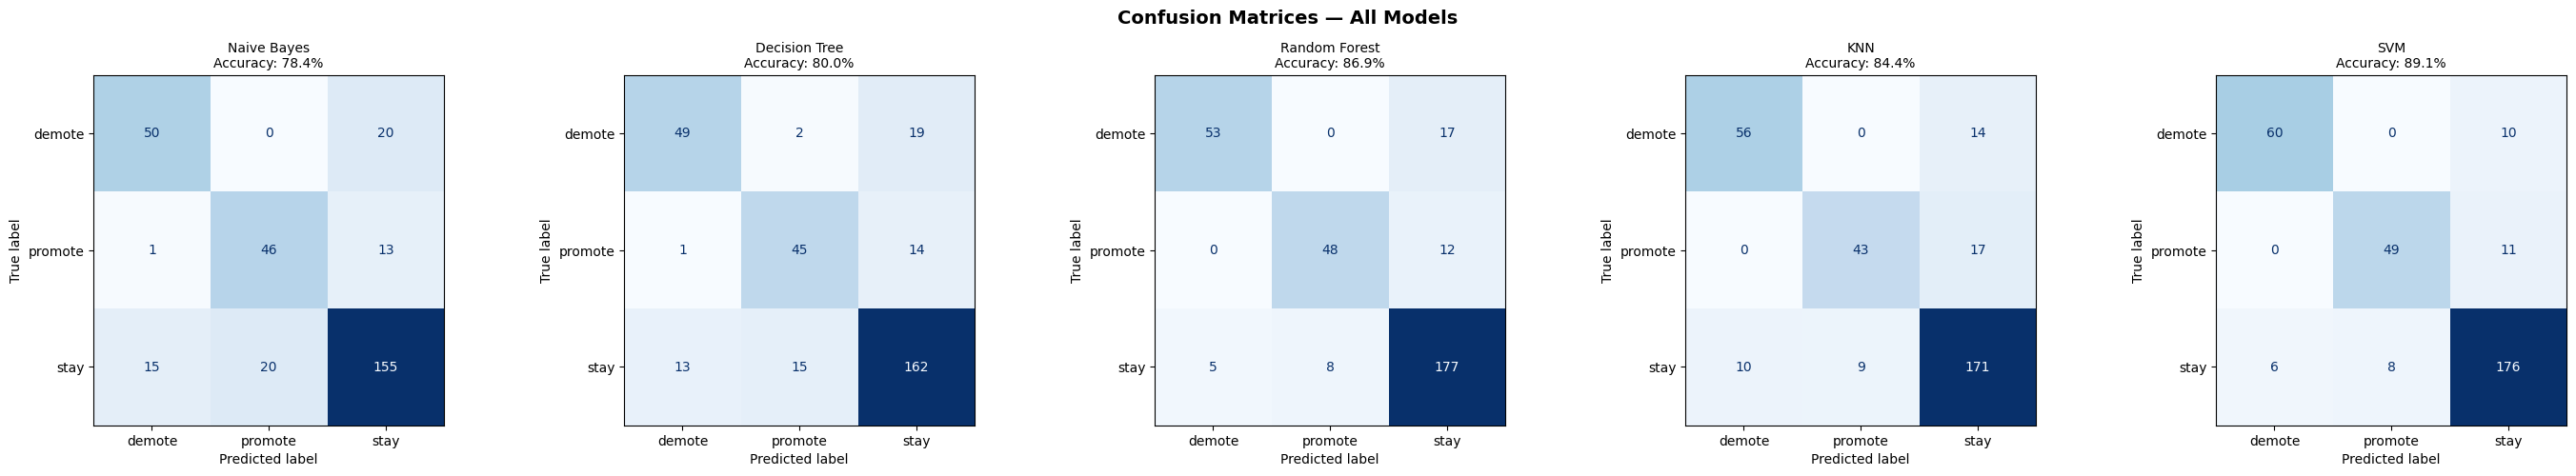

Saved: confusion_matrices.png


In [ ]:
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

label_names = le.classes_.tolist()   # ['demote', 'promote', 'stay']
results = {}

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, trained.items()):
    if name in ['KNN', 'SVM']:
        y_pred = model.predict(X_test_sc)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {'accuracy': acc, 'predictions': y_pred}

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {acc:.1%}', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

Running 5-fold cross-validation (takes ~30 seconds)...

        Model Test Accuracy CV Mean CV Std
          SVM         89.1%   84.4%  ±2.6%
Random Forest         86.9%   84.1%  ±4.5%
          KNN         84.4%   60.3%  ±5.1%
Decision Tree         80.0%   75.6%  ±3.4%
  Naive Bayes         78.4%   76.9%  ±3.9%


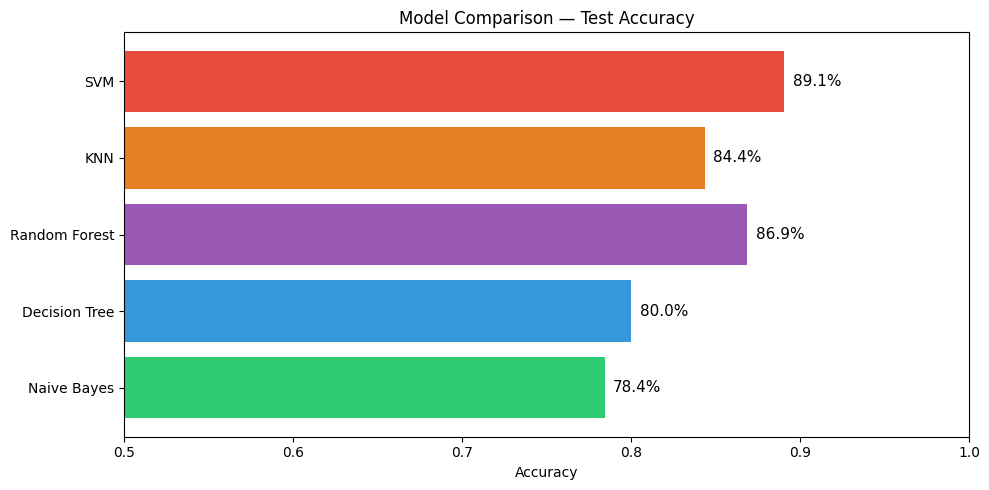

Saved: model_comparison.png


In [ ]:
from sklearn.model_selection import cross_val_score

print("Running 5-fold cross-validation (takes ~30 seconds)...\n")

comparison = []
for name, model in trained.items():
    if name in ['K NN', 'SVM']:
        cv_scores = cross_val_score(model, X_test_sc, y_test, cv=5, scoring='accuracy')
    else:
        cv_scores = cross_val_score(model, X_test, y_test, cv=5, scoring='accuracy')

    test_acc = results[name]['accuracy']
    comparison.append({
        'Model':        name,
        'Test Accuracy': f"{test_acc:.1%}",
        'CV Mean':      f"{cv_scores.mean():.1%}",
        'CV Std':       f"±{cv_scores.std():.1%}",
    })

comp_df = pd.DataFrame(comparison)
comp_df = comp_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(comp_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = [r['Model'] for r in comparison]
accs  = [results[n]['accuracy'] for n in names]
bars  = ax.barh(names, accs, color=['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c'])
ax.set_xlabel('Accuracy')
ax.set_xlim(0.5, 1.0)
ax.set_title('Model Comparison — Test Accuracy')
for bar, val in zip(bars, accs):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

In [ ]:
# Identify best model automatically
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = trained[best_name]
print(f"Best model: {best_name}")
print(f"Accuracy:   {results[best_name]['accuracy']:.1%}\n")

if best_name in ['KNN', 'SVM']:
    y_best_pred = best_model.predict(X_test_sc)
else:
    y_best_pred = best_model.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_best_pred, target_names=label_names))

# Feature importance (only for tree-based models)
if best_name in ['Random Forest', 'Decision Tree']:
    fi = pd.DataFrame({
        'Feature':    FEATURES,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\n=== FEATURE IMPORTANCE ===")
    print(fi.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(fi['Feature'], fi['Importance'], color='#3498db')
    ax.set_title(f'Feature Importance — {best_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: feature_importance.png")


Best model: SVM
Accuracy:   89.1%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      demote       0.91      0.86      0.88        70
     promote       0.86      0.82      0.84        60
        stay       0.89      0.93      0.91       190

    accuracy                           0.89       320
   macro avg       0.89      0.87      0.88       320
weighted avg       0.89      0.89      0.89       320



In [ ]:
# EXPLANATION:
# We save the trained model so we do not have to retrain it every time.
# joblib saves it as a file. We also save the scaler and label encoder.

import joblib

joblib.dump(best_model, 'pearl_model.pkl')
joblib.dump(scaler,     'pearl_scaler.pkl')
joblib.dump(le,         'pearl_label_encoder.pkl')

print(f"Saved: pearl_model.pkl       ({best_name})")
print("Saved: pearl_scaler.pkl")
print("Saved: pearl_label_encoder.pkl")



Saved: pearl_model.pkl       (SVM)
Saved: pearl_scaler.pkl
Saved: pearl_label_encoder.pkl


In [ ]:
# EXPLANATION:
# This simulates a patient who just finished a session.
# We feed their numbers in and the model tells us what to do.

sample = pd.DataFrame([{
    'level_number':               3,
    'session_number':             7,
    'sessions_on_current_level':  5,
    'session_accuracy':           42.0,
    'correct_placements':         5,
    'wrong_placements':           8,
    'rounds_completed':           4,
    'session_duration_sec':       310.0,
    'avg_reaction_time_ms':       3100.0,
    'accuracy_last_3_sessions':   45.0,
    'accuracy_trend':             -3.5,
    'time_trend':                 12.0,
}])

if best_name in ['KNN', 'SVM']:
    sample_input = scaler.transform(sample[FEATURES])
else:
    sample_input = sample[FEATURES]

pred_encoded = best_model.predict(sample_input)[0]
pred_label   = le.inverse_transform([pred_encoded])[0]

if hasattr(best_model, 'predict_proba'):
    if best_name in ['KNN', 'SVM']:
        probs = best_model.predict_proba(sample_input)[0]
    else:
        probs = best_model.predict_proba(sample_input)[0]
    print("Probabilities:")
    for cls, prob in zip(le.classes_, probs):
        print(f"  {cls}: {prob:.1%}")

print(f"\nPrediction: {pred_label.upper()}")
print("Explanation: Patient is performing poorly and declining — recommend demotion.")



Probabilities:
  demote: 79.2%
  promote: 0.7%
  stay: 20.1%

Prediction: DEMOTE
Explanation: Patient is performing poorly and declining — recommend demotion.


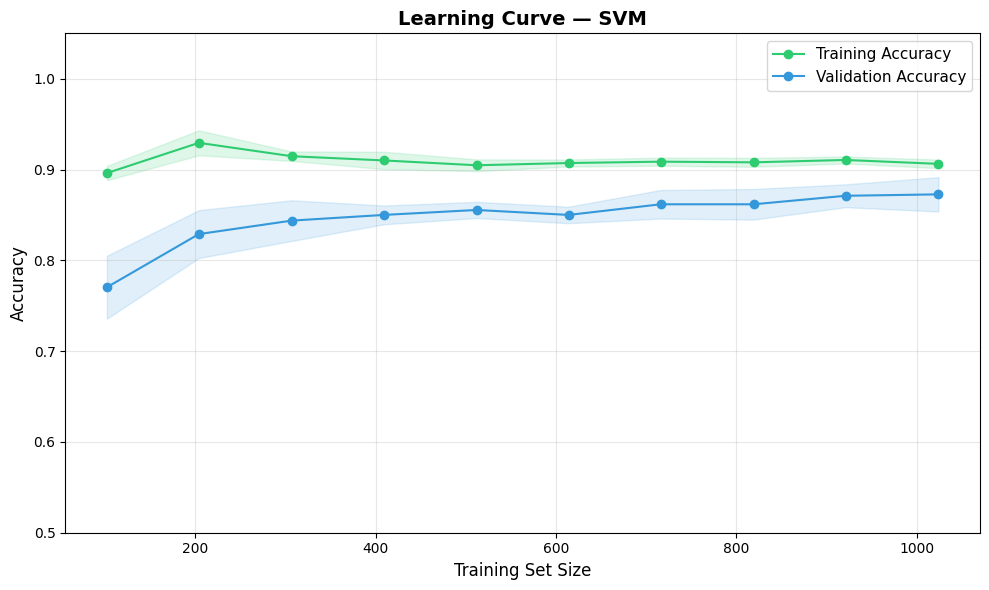

Saved: learning_curve.png


In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Use the final selected model from your notebook
model_for_curve = best_model

# Choose the right feature matrix
# SVM and KNN use scaled data; your final model is SVM
X_curve = X_train_sc

train_sizes, train_scores, val_scores = learning_curve(
    model_for_curve,
    X_curve,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Training Accuracy')
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='#2ecc71')

ax.plot(train_sizes, val_mean, 'o-', color='#3498db', label='Validation Accuracy')
ax.fill_between(train_sizes, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='#3498db')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curve — SVM', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: learning_curve.png")

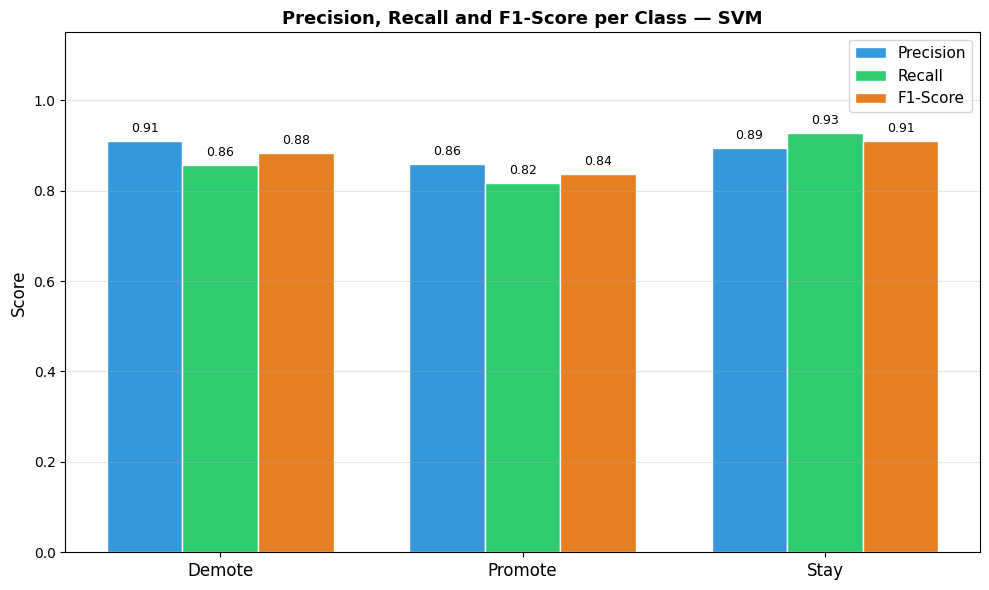

Saved: per_class_metrics.png


In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

# Use best model predictions already computed in your notebook
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_best_pred, labels=[0,1,2]
)

label_names_display = ['Demote', 'Promote', 'Stay']
x = np.arange(len(label_names_display))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision',
       color='#3498db', edgecolor='white')
ax.bar(x,         recall,    width, label='Recall',
       color='#2ecc71', edgecolor='white')
ax.bar(x + width, f1,        width, label='F1-Score',
       color='#e67e22', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(label_names_display, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Precision, Recall and F1-Score per Class — SVM',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)
    ax.text(i,         r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: per_class_metrics.png")

In [ ]:
# Download all 3 files to your computer
files.download('pearl_model.pkl')
files.download('pearl_scaler.pkl')
files.download('pearl_label_encoder.pkl')
files.download('confusion_matrices.png')
files.download('model_comparison.png')
files.download('learning_curve.png')
files.download('per_class_metrics.png')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>